## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [2]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [3]:
NUTS0 = 'GR'
NUTS2 = 'Peloponnese'
NUTS2_ID = 'EL65'

In [4]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.794372,2.906276,5.850324,8.798801,NaN,NaN,NaN,3.135829,NaN,NaN,NaN,5.967315,NaN,NaN,NaN,10.544655,97.275135,162.097517,326.486088,326.884315,325.385350,10.496302,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315,0,16.541667,20.083333,42.730496,870.594972,45.0,-2.0,47.0,6.833333,27.833333,27.833333,6.833333,1562.0,326.0,12.0,72.771443,683.0,74.0,74.0,683.0,13006.0,61418.0,20061.0,94485.0,12847.0,57546.0,23167.0,93560.0,3584.39,NaN,NaN
1,2009-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.894878,3.788358,5.841618,7.915540,NaN,NaN,NaN,4.144929,NaN,NaN,NaN,6.030234,NaN,NaN,NaN,9.150209,57.888997,130.297894,282.936824,283.656469,279.573034,9.018485,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.0,1.0,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469,0,16.708333,20.083333,43.659420,877.615140,45.0,-1.0,46.0,7.166667,28.166667,28.166667,6.833333,1438.0,283.0,16.0,70.846963,625.0,69.0,69.0,614.0,11064.0,48335.0,13835.0,73234.0,10713.0,46970.0,15666.0,73349.0,2491.26,NaN,NaN
2,2009-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.877874,5.112057,7.994965,10.877874,NaN,NaN,NaN,5.175483,NaN,NaN,NaN,8.026678,NaN,NaN,NaN,2.382990,22.702147,30.768818,73.854602,73.872681,952.162866,30.714931,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.0,1.0,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.133277,55.424007,349.428395,15.049726,0.000000,87.983581,22,20,20,9,9,4,1,1,2,1.630526,13.933265,73.872681,0,18.000000,19.333333,43.939394,866.550109,44.0,0.0,44.0,8.333333,26.666667,29.000000,8.000000,291.0,73.0,0.0,83.

In [5]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_LT15']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_LT15']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [6]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y15-64']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y15-64']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [7]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_GE65']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_GE65']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [8]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [9]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_LT15']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_LT15']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [10]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y15-64']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y15-64']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [11]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_GE65']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_GE65']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [12]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [13]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [14]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [15]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [16]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','monthly_lst_min','monthly_lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'mosq_pred_acc','mosq_pred_mean',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min',
 'distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'cases']

In [17]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [18]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [19]:
data = []

for year in years[1:]:
    for month in months:
        for region in nuts3_units:
            df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'NUTS3_ID': region, 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_prev_month.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_prev_month.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_prev_month.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_prev_month.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_prev_month.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_prev_month.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_prev_month.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_prev_month.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_prev_month.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_prev_month.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_prev_month.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_prev_month.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['monthly_lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['monthly_lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_prev_month.iloc[0]['acc_rainfall_jan'],

                        'mosq_pred_acc': df_prev_month.iloc[0]['mosq_pred_acc'],
                        'mosq_pred_mean': df_prev_month.iloc[0]['mosq_pred_mean'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_prev_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_prev_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_prev_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_prev_year.iloc[0]['lc_type1'],
                        'lc_type2': df_prev_year.iloc[0]['lc_type2'],
                        'lc_type3': df_prev_year.iloc[0]['lc_type3'],
                        'lc_type4': df_prev_year.iloc[0]['lc_type4'],
                        'lc_type5': df_prev_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_prev_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_prev_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_prev_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_prev_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_prev_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_prev_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_prev_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_prev_year.iloc[0]['flow_accu_200m'],

                        'distance_to_coast_min': df_prev_year.iloc[0]['distance_to_coast_min'],
                        'distance_to_river_min': df_prev_year.iloc[0]['distance_to_river_min'],
                        'slope_mean_1km_min': df_prev_year.iloc[0]['slope_mean_1km_min'],
                        'aspect_mean_200m_min': df_prev_year.iloc[0]['aspect_mean_200m_min'],
                        'elevation_mean_1km_min': df_prev_year.iloc[0]['elevation_mean_1km_min'],
                        'hillshade_mean_1km_min': df_prev_year.iloc[0]['hillshade_mean_1km_min'],
                        'fs_area_1km_min': df_prev_year.iloc[0]['fs_area_1km_min'],
                        'flow_accu_200m_min': df_prev_year.iloc[0]['flow_accu_200m_min'],

                        'distance_to_coast_max': df_prev_year.iloc[0]['distance_to_coast_max'],
                        'distance_to_river_max': df_prev_year.iloc[0]['distance_to_river_max'],
                        'slope_mean_1km_max': df_prev_year.iloc[0]['slope_mean_1km_max'],
                        'aspect_mean_200m_max': df_prev_year.iloc[0]['aspect_mean_200m_max'],
                        'elevation_mean_1km_max': df_prev_year.iloc[0]['elevation_mean_1km_max'],
                        'hillshade_mean_1km_max': df_prev_year.iloc[0]['hillshade_mean_1km_max'],
                        'fs_area_1km_max': df_prev_year.iloc[0]['fs_area_1km_max'],
                        'flow_accu_200m_max': df_prev_year.iloc[0]['flow_accu_200m_max'],

                        'distance_to_coast_std': df_prev_year.iloc[0]['distance_to_coast_std'],
                        'distance_to_river_std': df_prev_year.iloc[0]['distance_to_river_std'],
                        'slope_mean_1km_std': df_prev_year.iloc[0]['slope_mean_1km_std'],
                        'aspect_mean_200m_std': df_prev_year.iloc[0]['aspect_mean_200m_std'],
                        'elevation_mean_1km_std': df_prev_year.iloc[0]['elevation_mean_1km_std'],
                        'hillshade_mean_1km_std': df_prev_year.iloc[0]['hillshade_mean_1km_std'],
                        'fs_area_1km_std': df_prev_year.iloc[0]['fs_area_1km_std'],
                        'flow_accu_200m_std': df_prev_year.iloc[0]['flow_accu_200m_std'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],
                    
                        'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

In [20]:
dataset_monthly[(dataset_monthly['NUTS3_ID'] == 'EL651') & (dataset_monthly['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_NAME'])

,dt_placement,NUTS3_ID,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,cases
514,2023-01,EL651,22.468935,37.523367,1,2023,0.405750,0.185802,-0.313906,-0.185802,0.381948,0.186948,-0.295265,-0.186948,0.052742,0.061714,0.056359,0.061714,10.247172,10.247172,NaN,NaN,NaN,3.626534,3.626534,NaN,NaN,NaN,6.936853,6.936853,NaN,NaN,NaN,0.854808,12.343519,5.831603,114.256771,148.896777,180.779681,180.779681,18.5,18.176471,43.277311,798.044485,41.0,-1.0,42.0,8.166667,29.0,29.0,7.0,1563.0,184.0,19.0,61.810307,448.0,65.0,65.0,286.0,950.184713,30.651120,11822.299858,1369.518699,14.60828,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.52638,6362.356714,950.036792,9.908659,59.612108,342.474145,14.66476,0.026427,241.108019,22,20,20,9,9,4,1,1,2,11253.0,53176.0,20951.0,85380.0,10474.0,50631.0,23864.0,84969.0,2824.9,4639.0,5721.0,0
517,2023-02,EL651,22.468935,37.523367,2,2023,0.443476,0.169970,-0.365893,-0.169970,0.435389,0.169013,-0.361343,-0.169013,0.052237,0.064771,0.047726,0.064771,11.054545,10.247172,11.054545,NaN,NaN,2.104430,3.626534,2.10443,NaN,NaN,6.579487,6.936853,6.579487,NaN,NaN,-1.410279,16.641777,0.749513,11.160704,11.330284,21.838948,201.766056,18.5,18.176471,43.277311,798.044485,41.0,-1.0,42.0,8.166667,29.0,29.0,7.0,1563.0,184.0,19.0,61.810307,448.0,65.0,65.0,286.0,745.869427,26.638194,11822.299858,1369.518699,14.60828,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.52638,6362.356714,950.036792,9.908659,59.612108,342.474145,14.66476,0.026427,241.108019,22,20,20,9,9,4,1,1,2,11253.0,53176.0,20951.0,85380.0,10474.0,50631.0,23864.0,84969.0,2824.9,4639.0,5721.0,0
520,2023-03,EL651,22.468935,37.523367,3,2023,0.468705,0.132804,-0.399143,-0.132804,0.458111,0.130823,-0.391679,-0.130823,0.046265,0.054993,0.035141,0.054993,15.630373,10.247172,11.054545,15.630373,NaN,5.176921,3.626534,2.10443,5.176921,NaN,10.403647,6.936853,6.579487,10.403647,NaN,1.929164,23.043937,2.966531,0.491672,7.823974,90.565797,293.728509,18.5,18.176471,43.277311,798.044485,41.0,-1.0,42.0,8.166667,29.0,29.0,7.0,1563.0,184.0,19.0,61.810307,448.0,65.0,65.0,286.0,867.977707,27.999281,11822.299858,1369.518699,14.60828,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.52638,6362.356714,950.036792,9.908659,59.612108,342.474145,14.66476,0.026427,

In [21]:
dataset_operational[(dataset_operational['NUTS3_ID'] == 'EL651') & (dataset_operational['year'] == 2023)]

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
468,EL651,2023,1,22.468935,37.523367,0.393399,0.166302,-0.300833,-0.166302,0.357398,0.169663,-0.269435,-0.169663,0.048486,0.055404,0.051405,0.055404,12.011767,8.743046,11.508418,12.894657,12.894657,4.764574,1.531919,2.557161,1.503041,1.503041,8.388171,5.137483,7.032790,7.198849,7.198849,0.787714,16.687857,1.496967,0.010515,0.164022,44.296323,956.842897,888.248408,28.653174,16.958333,21.25,48.295455,843.277786,40.0,-4.0,44.0,27.5,6.666667,27.5,6.666667,951.0,208.0,9.0,63.434959,348.0,161.0,348.0,161.0,22,20,20,9,9,4,1,1,11822.299858,1369.518699,14.60828,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.52638,6362.356714,950.036792,9.908659,59.612108,342.474145,14.66476,0.026427,241.108019,11253.0,53176.0,20951.0,85380.0,10474.0,50631.0,23864.0,84969.0,2824.9,4639.0,5721.0,0
471,EL651,2023,2,22.468935,37.523367,0.405750,0.185802,-0.313906,-0.185802,0.381948,0.186948,-0.295265,-0.186948,0.052742,0.061714,0.056359,0.061714,10.247172,10.247172,NaN,NaN,NaN,3.626534,3.626534,NaN,NaN,NaN,6.936853,6.936853,NaN,NaN,NaN,0.854808,12.343519,5.831603,114.256771,148.896777,180.779681,180.779681,950.184713,30.651120,16.958333,21.25,48.295455,843.277786,40.0,-4.0,44.0,27.5,6.666667,27.5,6.666667,951.0,208.0,9.0,63.434959,348.0,161.0,348.0,161.0,22,20,20,9,9,4,1,1,11822.299858,1369.518699,14.60828,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.52638,6362.356714,950.036792,9.908659,59.612108,342.474145,14.66476,0.026427,241.108019,11253.0,53176.0,20951.0,85380.0,10474.0,50631.0,23864.0,84969.0,2824.9,4639.0,5721.0,0
474,EL651,2023,3,22.468935,37.523367,0.443476,0.169970,-0.365893,-0.169970,0.435389,0.169013,-0.361343,-0.169013,0.052237,0.064771,0.047726,0.064771,11.054545,10.247172,11.054545,NaN,NaN,2.104430,3.626534,2.104430,NaN,NaN,6.579487,6.936853,6.579487,NaN,NaN,-1.410279,16.641777,0.749513,11.160704,11.330284,21.838948,201.766056,745.869427,26.638194,16.958333,21.25,48.295455,843.277786,40.0,-4.0,44.0,27.5,6.666667,27.5,6.666667,951.0,208.0,9.0,63.434959,348.0,161.0,348.0,161.0,22,20,20,9,9,4,1,1,11822.299858,1369.518699,14.60828,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.52638,6362.356714,950.036792,9.908659,5

In [22]:
dataset_operational

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL651,2010,1,22.468935,37.523367,0.412660,0.182239,-0.157283,-0.182239,0.405314,0.184532,-0.146387,-0.184532,0.042946,0.047402,0.070356,0.047402,11.267300,8.798801,8.742830,13.816667,13.816667,5.649060,3.135829,1.275127,2.851445,2.851445,8.458180,5.967315,5.008978,8.334056,8.334056,2.544634,17.667770,5.571429,17.119964,43.394291,172.307688,1567.884215,244.490446,7.886789,16.541667,20.083333,42.730496,870.594972,45.0,-2.0,47.0,6.833333,27.833333,27.833333,6.833333,1562.0,326.0,12.0,72.771443,683.0,74.0,74.0,683.0,31,20,20,9,9,4,1,1,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.0,1.0,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,13006.0,61418.0,20061.0,94485.0,12847.0,57546.0,23167.0,93560.0,3584.39,10066.0,11627.0,0
1,EL652,2010,1,22.674305,37.912693,0.412862,0.192533,-0.155178,-0.192533,0.396241,0.195914,-0.135882,-0.195914,0.041172,0.043785,0.061378,0.043785,11.269768,7.915540,8.003090,13.382302,13.382302,5.845578,4.144929,1.419366,3.196504,3.196504,8.557673,6.030234,4.711228,8.289403,8.289403,2.505056,17.614494,5.981771,17.231229,34.249629,185.151847,1442.920357,87.269663,2.815150,16.708333,20.083333,43.659420,877.615140,45.0,-1.0,46.0,7.166667,28.166667,28.166667,6.833333,1438.0,283.0,16.0,70.846963,625.0,69.0,69.0,614.0,31,20,30,9,9,1,1,1,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.0,1.0,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,11064.0,48335.0,13835.0,73234.0,10713.0,46970.0,15666.0,73349.0,2491.26,7451.0,6490.0,0
2,EL653,2010,1,22.303892,36.998594,0.360534,0.195488,-0.106221,-0.195488,0.336623,0.196249,-0.077988,-0.196249,0.041675,0.039469,0.051622,0.039469,13.402890,10.877874,10.794781,15.509724,15.509724,7.757821,5.175483,3.255700,4.326524,4.326524,10.580355,8.026678,7.025241,9.918124,9.918124,5.550408,17.427959,1.052270,2.330283,6.243615,32.569753,296.575503,1326.641694,42.794893,18.000000,19.333333,43.939394,866.550109,44.0,0.0,44.0,8.333333,26.666667,29.000000,8.000000,291.0,73.0,0.0,83.946894,141.0,6.0,7.0,137.0,22,20,20,9,9,4,1,1,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,

<Axes: >

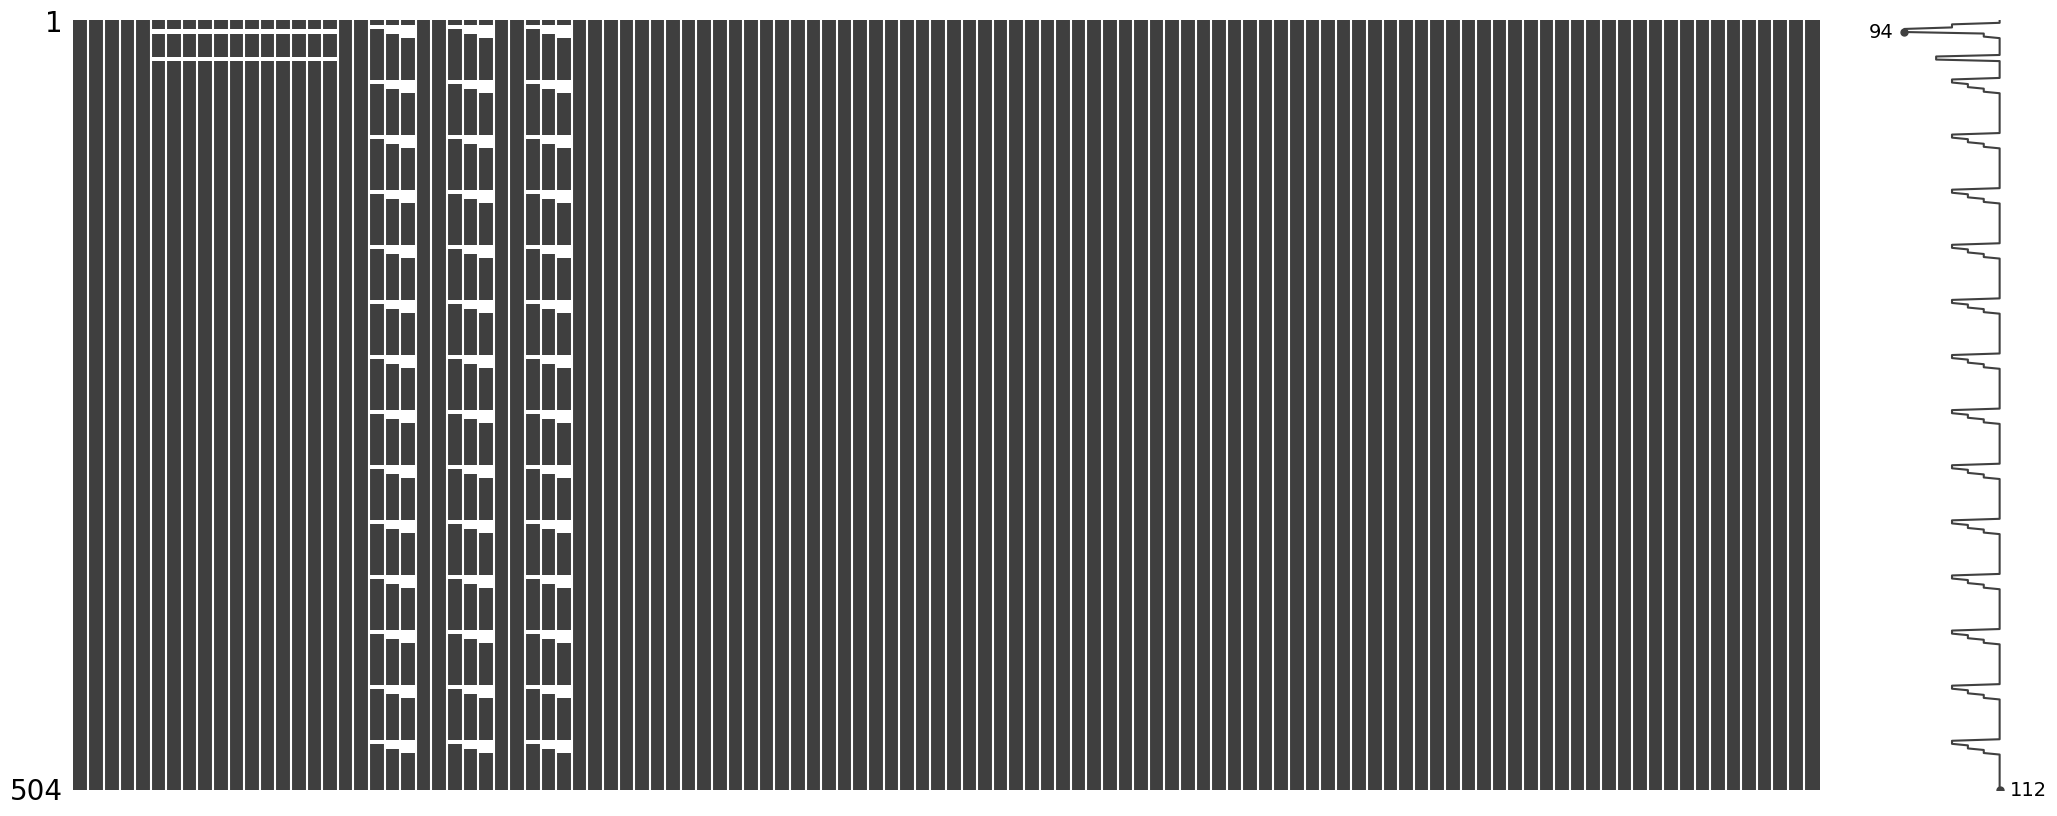

In [23]:
missingno.matrix(dataset_operational)

In [24]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
5,ndvi,1.1905
6,ndmi,1.1905
7,ndwi,1.1905
8,ndbi,1.1905
9,ndvi_mean,1.1905
...,...,...
25,lst_mar_night_mean,16.6667
26,lst_apr_night_mean,25.0000
29,lst_feb_mean,8.3333
30,lst_mar_mean,16.6667


<Axes: >

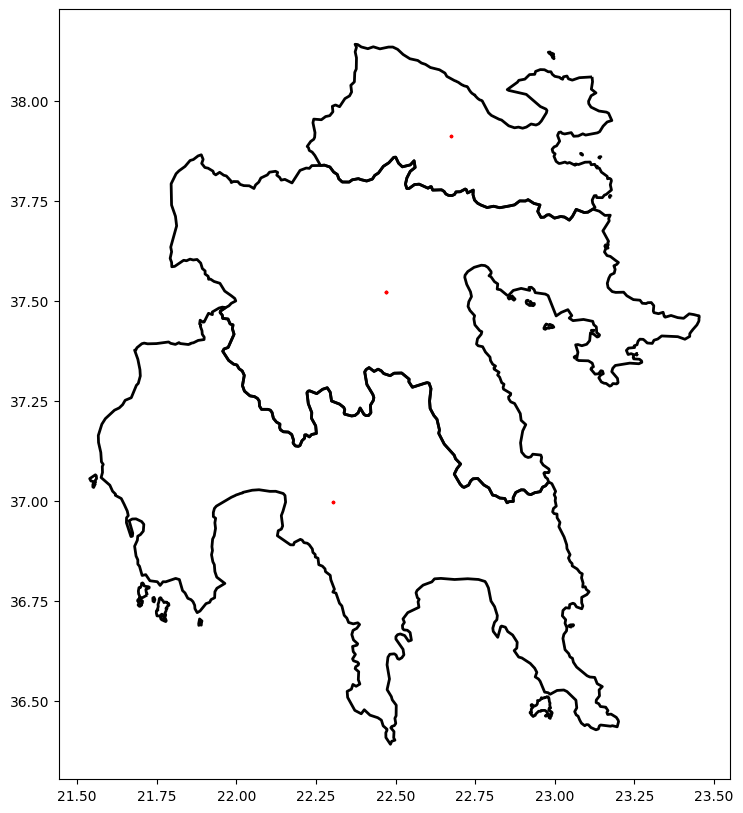

In [26]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_monthly[['NUTS3_ID']], geometry=gpd.points_from_xy(dataset_monthly.x, dataset_monthly.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [27]:
dataset_operational.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2010_2023.csv", encoding = enc, index = False)